# 📊 Actividad Diagnóstica — Análisis de Series de Tiempo
### Curso: Análisis Numérico para la Optimización · MA2008

---

**Objetivo:** Reconocer visualmente los componentes principales de una serie de tiempo  
(tendencia, estacionalidad, ruido y rezagos) y justificar su interpretación.

| Sección | Contenido |
|---------|-----------|
| **Parte 1** | Señal senoidal periódica y ruido blanco |
| **Parte 2** | Tests estadísticos (estacionariedad, ruido, tendencia) |
| **Parte 3** | Análisis de dos series reales |

> **Instrucciones:** Ejecuta cada celda en orden. Responde las preguntas  
> en las celdas de texto habilitadas para ello (celdas `Markdown` editables).

---


## 🔧 0. Configuración del entorno

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal, stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4a',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0a0',
    'ytick.color':      '#a0a0a0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETA = ['#00d4ff', '#ff6b6b', '#ffd700', '#7cfc00', '#ff69b4', '#da70d6']
print("✅ Entorno listo")


✅ Entorno listo


---
## 📡 Parte 1A — Señal Periódica Senoidal

Una señal senoidal pura es el ejemplo más simple de **serie periódica**.  
Está completamente determinada por su amplitud, frecuencia y fase:

$$x(t) = A \cdot \sin(2\pi f t + \phi)$$


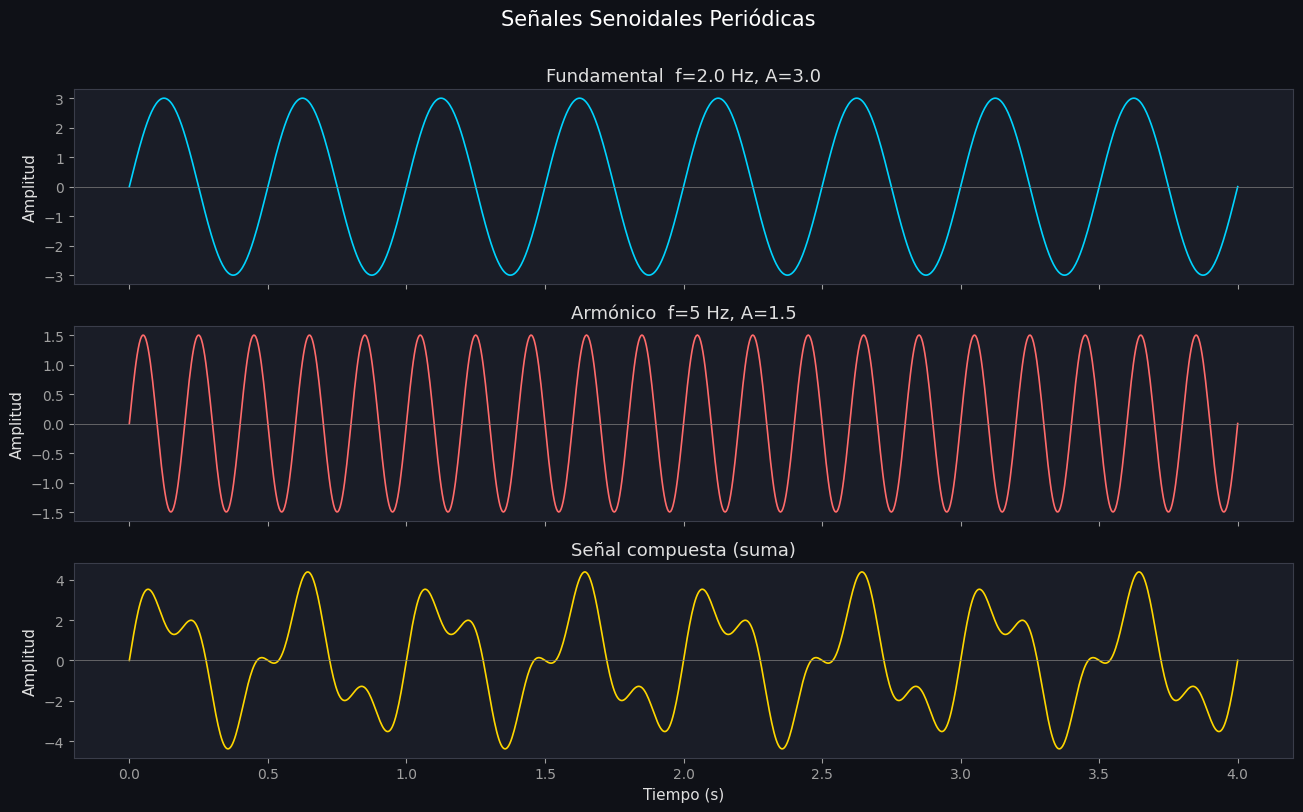

Período fundamental T = 0.5 s


In [4]:
np.random.seed(42)
t  = np.linspace(0, 4, 1000)          # 4 segundos, 1000 puntos
A, f, phi = 3.0, 2.0, 0.0            # amplitud, frecuencia (Hz), fase

seno   = A * np.sin(2 * np.pi * f * t + phi)
seno2  = 1.5 * np.sin(2 * np.pi * 5 * t)   # armónico adicional
seno_c = seno + seno2                        # señal compuesta

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle("Señales Senoidales Periódicas", fontsize=15, color='white', y=1.01)

for ax, y, titulo, col in zip(axes,
    [seno, seno2, seno_c],
    [f"Fundamental  f={f} Hz, A={A}",
     "Armónico  f=5 Hz, A=1.5",
     "Señal compuesta (suma)"],
    PALETA):
    ax.plot(t, y, color=col, lw=1.2)
    ax.set_title(titulo)
    ax.set_ylabel("Amplitud")
    ax.axhline(0, color='gray', lw=0.5)

axes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.savefig("fig1_senoidal.png", dpi=120, bbox_inches='tight')
plt.show()
print("Período fundamental T =", round(1/f, 3), "s")


### 🔭 Espectro de Frecuencias (FFT)

La Transformada de Fourier descompone la señal en sus componentes de frecuencia.  
En una señal pura **esperamos picos únicos y estrechos**.


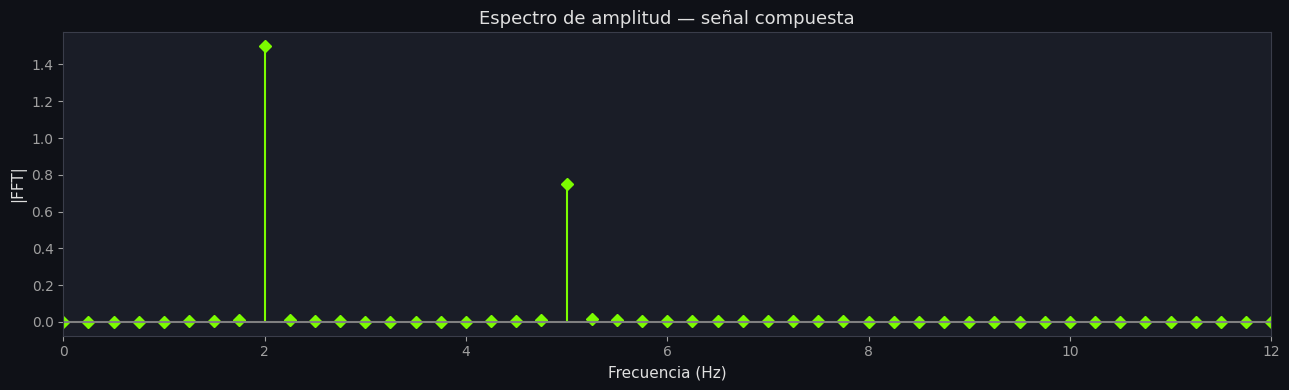

In [5]:
fs   = len(t) / t[-1]                        # frecuencia de muestreo
freq = np.fft.rfftfreq(len(t), 1/fs)
amp  = np.abs(np.fft.rfft(seno_c)) / len(t)

fig, ax = plt.subplots(figsize=(13, 4))
ax.stem(freq[:80], amp[:80], linefmt=PALETA[3], markerfmt='D',
        basefmt='gray')
ax.set_title("Espectro de amplitud — señal compuesta")
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("|FFT|")
ax.set_xlim(0, 12)
plt.tight_layout()
plt.savefig("fig2_fft.png", dpi=120, bbox_inches='tight')
plt.show()


---
## 🌫️ Parte 1B — Ruido Blanco

El **ruido blanco** es un proceso estocástico donde:
- Las observaciones son **independientes** entre sí (sin autocorrelación)
- Tienen **media cero** y **varianza constante**
- Su espectro de potencia es **plano** (todas las frecuencias con igual energía)

$$\epsilon_t \sim \mathcal{N}(0, \sigma^2), \quad \text{Cov}(\epsilon_t, \epsilon_s)=0 \ \forall t \neq s$$


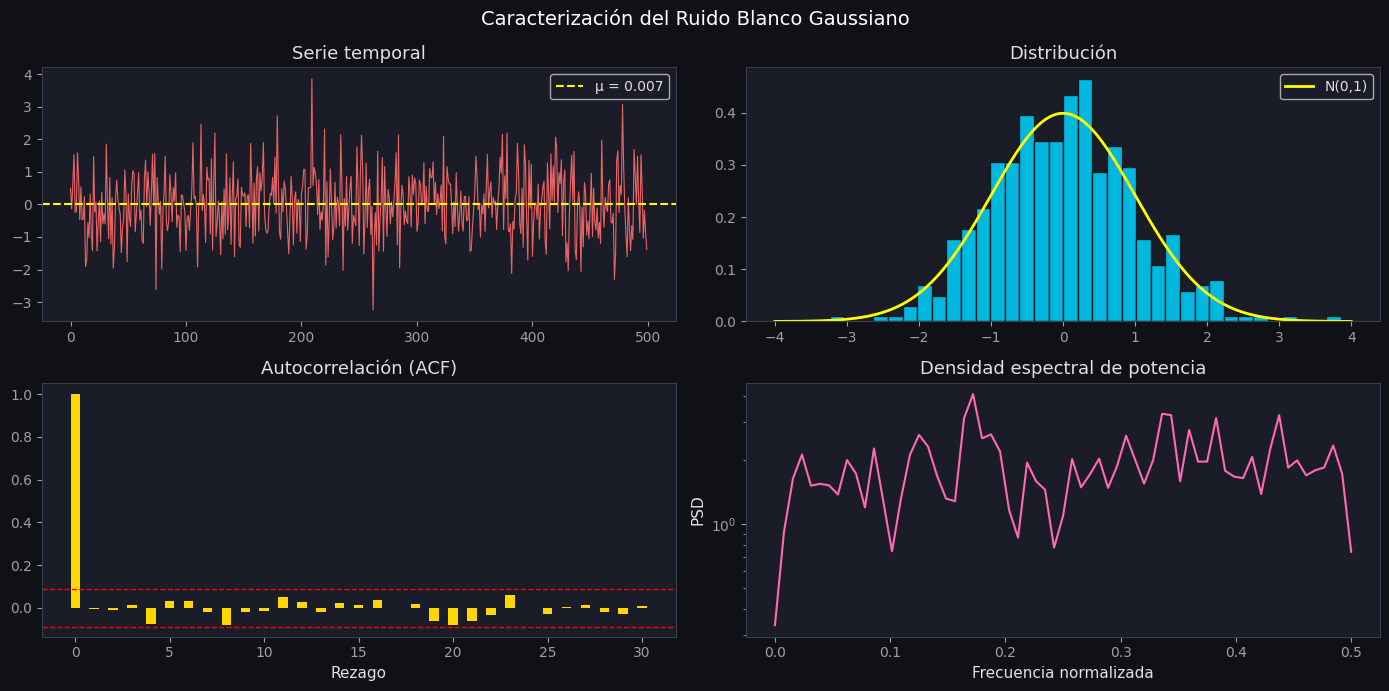

Media:     0.0068  (esperado ≈ 0)
Varianza:  0.9609  (esperado ≈ 1)
Curtosis:  0.2564 (esperado ≈ 0 para normal)
Asimetría: 0.1796  (esperado ≈ 0)


In [6]:
N    = 500
ruid = np.random.normal(0, 1, N)
t_r  = np.arange(N)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Caracterización del Ruido Blanco Gaussiano", fontsize=14, color='white')

# Serie temporal
axes[0,0].plot(t_r, ruid, color=PALETA[1], lw=0.8, alpha=0.9)
axes[0,0].axhline(ruid.mean(), color='yellow', lw=1.5, ls='--',
                  label=f'μ = {ruid.mean():.3f}')
axes[0,0].set_title("Serie temporal")
axes[0,0].legend()

# Histograma
axes[0,1].hist(ruid, bins=35, color=PALETA[0], edgecolor='#0f1117',
               density=True, alpha=0.85)
xn = np.linspace(-4, 4, 200)
axes[0,1].plot(xn, stats.norm.pdf(xn), color='yellow', lw=2, label='N(0,1)')
axes[0,1].set_title("Distribución")
axes[0,1].legend()

# ACF
nlags = 30
acf_vals = acf(ruid, nlags=nlags)
lag_x    = np.arange(nlags+1)
conf     = 1.96 / np.sqrt(N)
axes[1,0].bar(lag_x, acf_vals, color=PALETA[2], width=0.5)
axes[1,0].axhline( conf, color='red', ls='--', lw=1)
axes[1,0].axhline(-conf, color='red', ls='--', lw=1)
axes[1,0].set_title("Autocorrelación (ACF)")
axes[1,0].set_xlabel("Rezago")

# Espectro potencia
freqs_r, psd = signal.welch(ruid, fs=1.0, nperseg=128)
axes[1,1].semilogy(freqs_r, psd, color=PALETA[4])
axes[1,1].set_title("Densidad espectral de potencia")
axes[1,1].set_xlabel("Frecuencia normalizada")
axes[1,1].set_ylabel("PSD")

plt.tight_layout()
plt.savefig("fig3_ruido_blanco.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Media:     {ruid.mean():.4f}  (esperado ≈ 0)")
print(f"Varianza:  {ruid.var():.4f}  (esperado ≈ 1)")
print(f"Curtosis:  {stats.kurtosis(ruid):.4f} (esperado ≈ 0 para normal)")
print(f"Asimetría: {stats.skew(ruid):.4f}  (esperado ≈ 0)")


---
## 🧪 Parte 2 — Tests Estadísticos Formales

Aplicaremos tres pruebas clave sobre distintas series sintéticas:

| Test | Hipótesis H₀ | Rechazar H₀ si |
|------|-------------|----------------|
| **ADF** (Augmented Dickey-Fuller) | Tiene raíz unitaria (NO estacionaria) | p < 0.05 → estacionaria |
| **KPSS** | Es estacionaria | p < 0.05 → NO estacionaria |
| **Ljung-Box** | No hay autocorrelación (ruido puro) | p < 0.05 → hay autocorrelación |


In [7]:
def run_tests(serie, nombre):
    print(f"\n{'═'*50}")
    print(f"  Serie: {nombre}")
    print(f"{'═'*50}")

    # ADF
    adf = adfuller(serie, autolag='AIC')
    print(f"\n[ADF]  estadístico={adf[0]:.4f}  p={adf[1]:.4f}")
    print(f"       → {'✅ ESTACIONARIA' if adf[1] < 0.05 else '❌ NO estacionaria'}")

    # KPSS
    kpss_r = kpss(serie, regression='c', nlags='auto')
    print(f"[KPSS] estadístico={kpss_r[0]:.4f}  p={kpss_r[1]:.4f}")
    print(f"       → {'❌ NO estacionaria' if kpss_r[1] < 0.05 else '✅ ESTACIONARIA'}")

    # Ljung-Box
    lb = acorr_ljungbox(serie, lags=[10], return_df=True)
    p_lb = lb['lb_pvalue'].values[0]
    print(f"[Ljung-Box lag=10] p={p_lb:.4f}")
    print(f"       → {'❌ Hay autocorrelación (no es ruido blanco)' if p_lb < 0.05 else '✅ Ruido blanco (sin autocorrelación)'}")

# Crear series de prueba
np.random.seed(0)
N = 300
ruido_b   = np.random.normal(0, 1, N)
caminata  = np.cumsum(np.random.normal(0, 1, N))       # random walk
tendencia = np.linspace(0, 10, N) + np.random.normal(0, 0.5, N)
seno_ts   = 3*np.sin(2*np.pi*np.arange(N)/12) + np.random.normal(0,0.3,N)

for serie, nombre in [(ruido_b,  "Ruido Blanco"),
                      (caminata, "Caminata Aleatoria (Random Walk)"),
                      (tendencia,"Serie con Tendencia Lineal"),
                      (seno_ts,  "Serie Estacional + Ruido")]:
    run_tests(serie, nombre)



══════════════════════════════════════════════════
  Serie: Ruido Blanco
══════════════════════════════════════════════════

[ADF]  estadístico=-17.8394  p=0.0000
       → ✅ ESTACIONARIA
[KPSS] estadístico=0.2257  p=0.1000
       → ✅ ESTACIONARIA
[Ljung-Box lag=10] p=0.1097
       → ✅ Ruido blanco (sin autocorrelación)

══════════════════════════════════════════════════
  Serie: Caminata Aleatoria (Random Walk)
══════════════════════════════════════════════════

[ADF]  estadístico=-0.8680  p=0.7983
       → ❌ NO estacionaria
[KPSS] estadístico=2.4436  p=0.0100
       → ❌ NO estacionaria
[Ljung-Box lag=10] p=0.0000
       → ❌ Hay autocorrelación (no es ruido blanco)

══════════════════════════════════════════════════
  Serie: Serie con Tendencia Lineal
══════════════════════════════════════════════════

[ADF]  estadístico=-0.3110  p=0.9239
       → ❌ NO estacionaria
[KPSS] estadístico=2.8310  p=0.0100
       → ❌ NO estacionaria
[Ljung-Box lag=10] p=0.0000
       → ❌ Hay autocorrelación

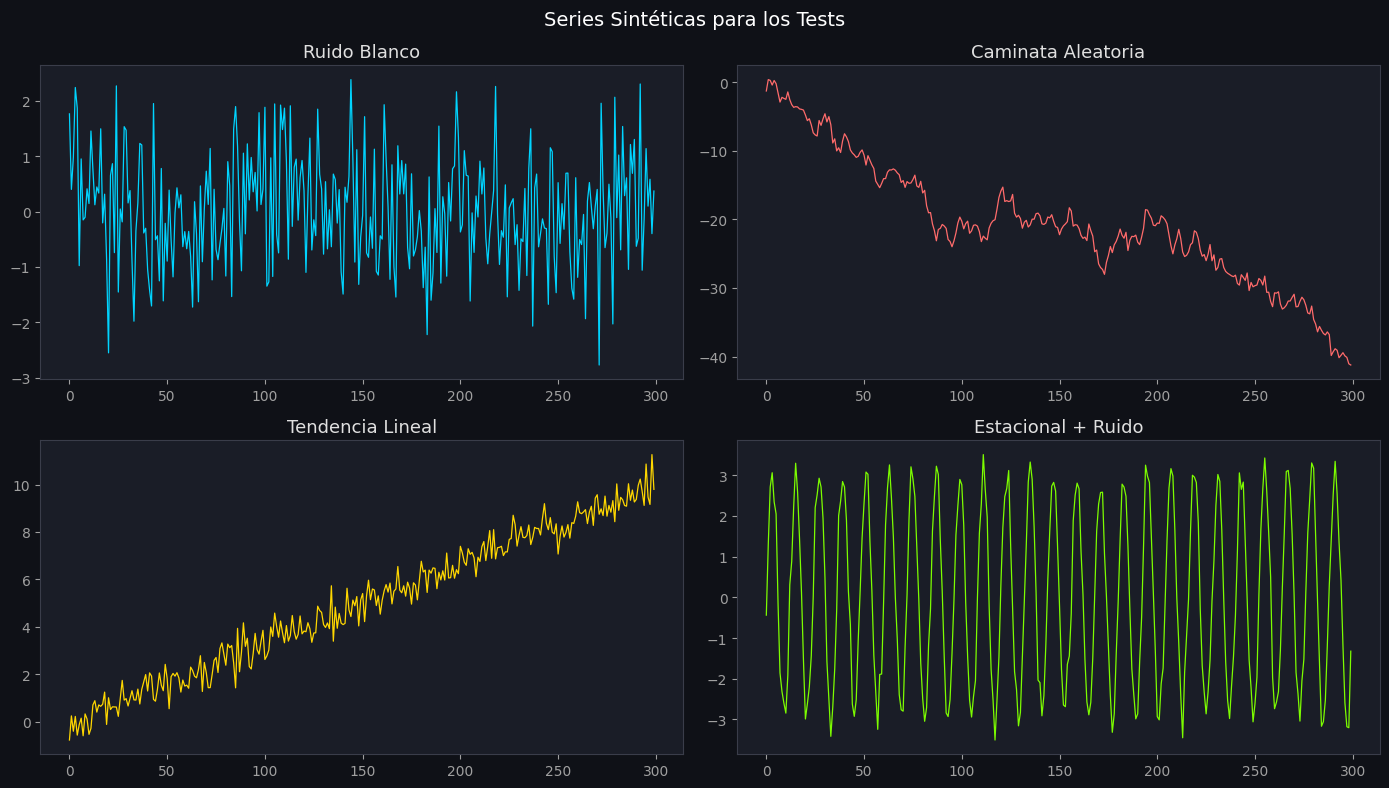

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Series Sintéticas para los Tests", fontsize=14, color='white')
series_s = [ruido_b, caminata, tendencia, seno_ts]
nombres_s = ["Ruido Blanco", "Caminata Aleatoria",
             "Tendencia Lineal", "Estacional + Ruido"]
for ax, y, nm, c in zip(axes.flat, series_s, nombres_s, PALETA):
    ax.plot(y, color=c, lw=0.9)
    ax.set_title(nm)
plt.tight_layout()
plt.savefig("fig4_series_sinteticas.png", dpi=120, bbox_inches='tight')
plt.show()


---
## 🌍 Parte 3 — Análisis de Dos Series Reales

Trabajaremos con dos series de datos reales integradas en `statsmodels`:

| Serie | Descripción |
|-------|-------------|
| **CO₂ atmosférico (Mauna Loa)** | Concentración mensual de CO₂ en ppm, 1958–2001 |
| **Pasajeros aéreos** | Pasajeros internacionales mensuales, 1949–1960 |


In [9]:
import statsmodels.api as sm

# ── Serie 1: CO2 ──
co2_raw = sm.datasets.co2.load_pandas().data
co2     = co2_raw['co2'].resample('MS').mean().ffill()

# ── Serie 2: Pasajeros aéreos ──
air_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
try:
    air = pd.read_csv(air_url, header=0, index_col=0, parse_dates=True,
                      squeeze=False)['Passengers']
except Exception:
    # Fallback local sintético si no hay internet
    idx = pd.date_range('1949-01', periods=144, freq='MS')
    base = np.tile(np.array([112,118,132,129,121,135,148,148,136,119,104,118]), 12)
    trend = np.linspace(0, 200, 144)
    air = pd.Series(base + trend + np.random.normal(0, 5, 144), index=idx,
                    name='Passengers')
    print("⚠️  Sin internet: usando serie de pasajeros sintética similar.")

print("CO2   — registros:", len(co2),  " | inicio:", co2.index[0].date(),
      " | fin:", co2.index[-1].date())
print("Aire  — registros:", len(air),  " | inicio:", air.index[0].date(),
      " | fin:", air.index[-1].date())


⚠️  Sin internet: usando serie de pasajeros sintética similar.
CO2   — registros: 526  | inicio: 1958-03-01  | fin: 2001-12-01
Aire  — registros: 144  | inicio: 1949-01-01  | fin: 1960-12-01


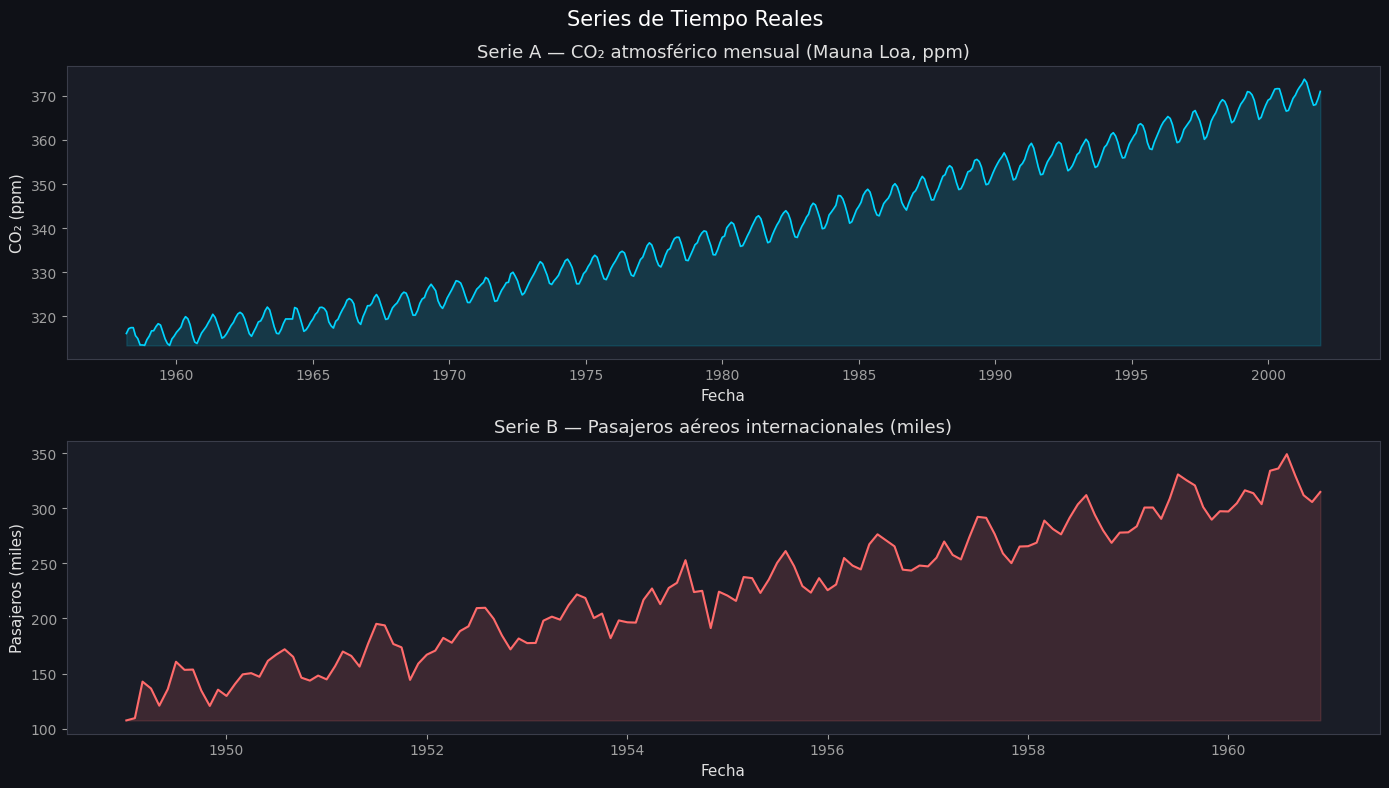

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Series de Tiempo Reales", fontsize=15, color='white')

ax1.plot(co2.index, co2.values, color=PALETA[0], lw=1.2)
ax1.set_title("Serie A — CO₂ atmosférico mensual (Mauna Loa, ppm)")
ax1.set_ylabel("CO₂ (ppm)")
ax1.fill_between(co2.index, co2.values, co2.min(), alpha=0.15, color=PALETA[0])

ax2.plot(air.index, air.values, color=PALETA[1], lw=1.5)
ax2.set_title("Serie B — Pasajeros aéreos internacionales (miles)")
ax2.set_ylabel("Pasajeros (miles)")
ax2.fill_between(air.index, air.values, air.min(), alpha=0.15, color=PALETA[1])

for ax in (ax1, ax2):
    ax.set_xlabel("Fecha")

plt.tight_layout()
plt.savefig("fig5_series_reales.png", dpi=120, bbox_inches='tight')
plt.show()


### 🔬 Descomposición Clásica

La descomposición separa la serie en tres partes:

$$X_t = T_t + S_t + R_t \quad \text{(modelo aditivo)}$$
$$X_t = T_t \times S_t \times R_t \quad \text{(modelo multiplicativo)}$$

Usamos **multiplicativo** cuando la amplitud estacional crece con el nivel de la serie.


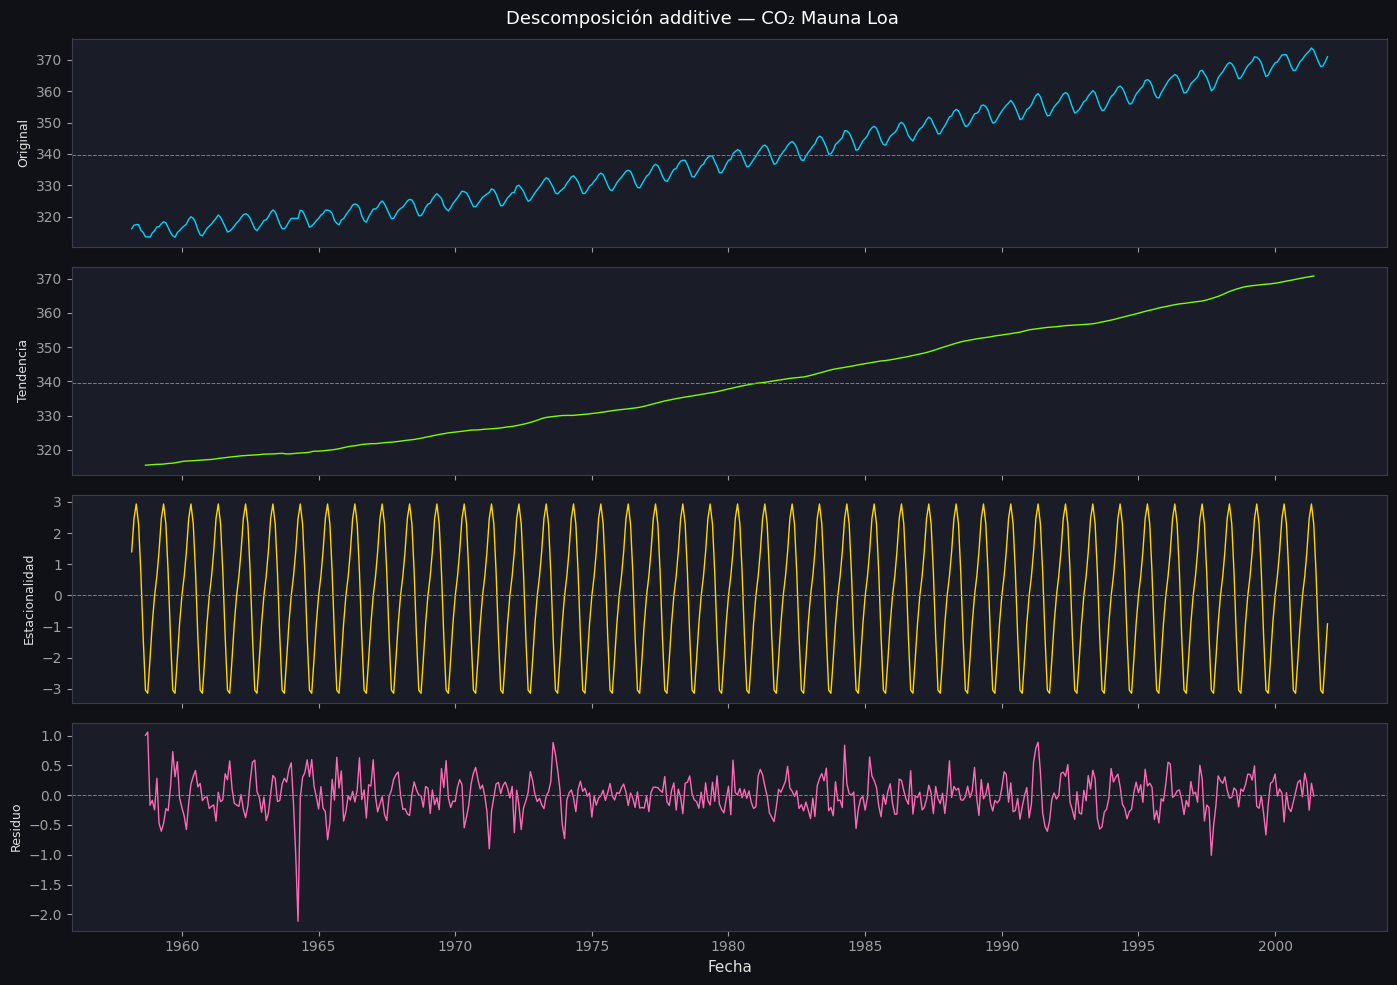

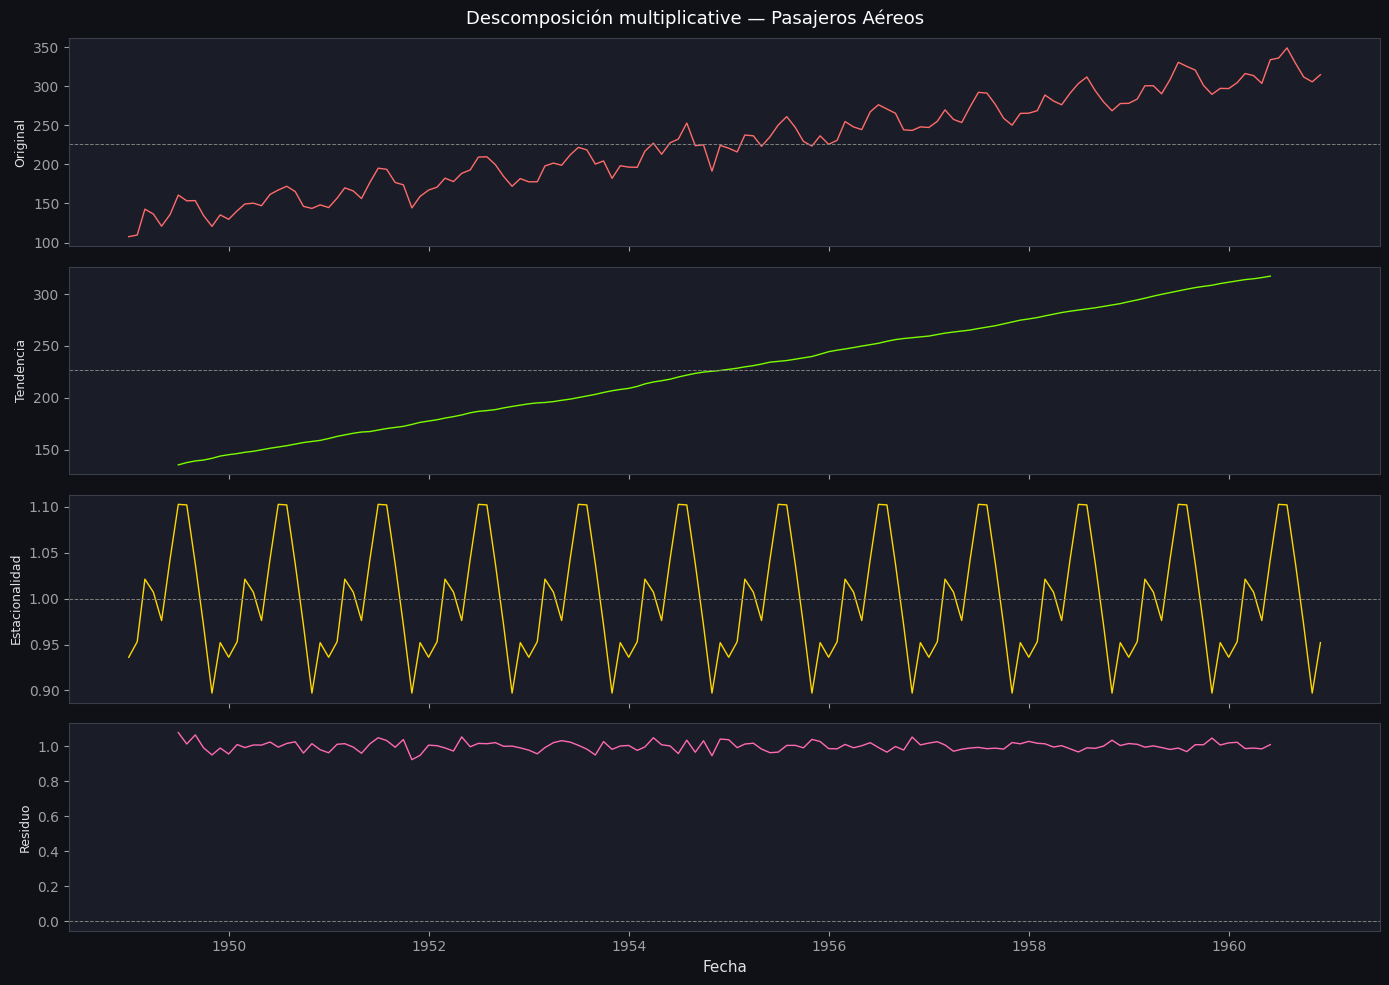

In [11]:
def plot_decompose(serie, nombre, modelo, periodo, color):
    dec = seasonal_decompose(serie.dropna(), model=modelo, period=periodo)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Descomposición {modelo} — {nombre}", fontsize=13, color='white')

    componentes = [('Original',      serie.dropna(),  color),
                   ('Tendencia',     dec.trend,       PALETA[3]),
                   ('Estacionalidad',dec.seasonal,    PALETA[2]),
                   ('Residuo',       dec.resid,       PALETA[4])]

    for ax, (nom, datos, c) in zip(axes, componentes):
        ax.plot(datos, color=c, lw=1.0)
        ax.set_ylabel(nom, fontsize=9)
        ax.axhline(datos.mean() if nom != 'Residuo' else 0,
                   color='gray', lw=0.7, ls='--')

    axes[-1].set_xlabel("Fecha")
    plt.tight_layout()
    plt.savefig(f"fig6_decomp_{nombre[:3].lower()}.png", dpi=120, bbox_inches='tight')
    plt.show()

plot_decompose(co2, "CO₂ Mauna Loa", "additive",       12, PALETA[0])
plot_decompose(air, "Pasajeros Aéreos", "multiplicative", 12, PALETA[1])


### 📐 Función de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)

La **ACF** mide la correlación de la serie con sus valores pasados a distintos rezagos.  
La **PACF** mide la correlación directa eliminando la influencia de rezagos intermedios.

- Picos significativos en ACF → **estructura de dependencia** (no es ruido)
- Picos que se repiten cada *k* rezagos → posible **estacionalidad de periodo k**


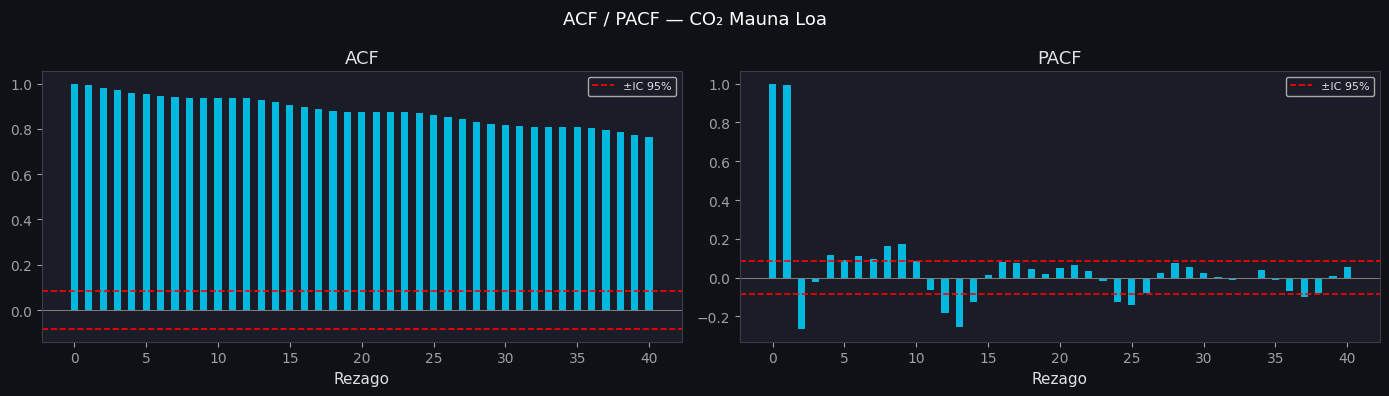

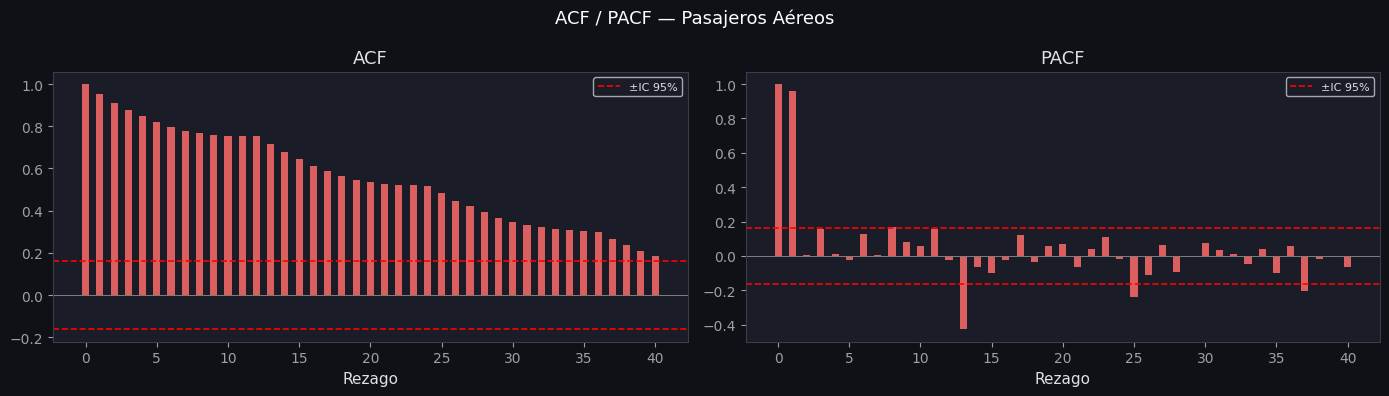

In [12]:
def plot_acf_pacf(serie, nombre, color, nlags=40):
    s = serie.dropna()
    acf_v  = acf(s,  nlags=nlags)
    pacf_v = pacf(s, nlags=nlags)
    lag_x  = np.arange(nlags+1)
    conf   = 1.96 / np.sqrt(len(s))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"ACF / PACF — {nombre}", fontsize=13, color='white')

    for ax, vals, titulo in [(ax1, acf_v, "ACF"), (ax2, pacf_v, "PACF")]:
        ax.bar(lag_x, vals, color=color, width=0.5, alpha=0.85)
        ax.axhline( conf, color='red', ls='--', lw=1.2, label='±IC 95%')
        ax.axhline(-conf, color='red', ls='--', lw=1.2)
        ax.axhline(0,     color='gray', lw=0.7)
        ax.set_title(titulo)
        ax.set_xlabel("Rezago")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"fig7_acf_{nombre[:3].lower()}.png", dpi=120, bbox_inches='tight')
    plt.show()

plot_acf_pacf(co2, "CO₂ Mauna Loa",     PALETA[0])
plot_acf_pacf(air, "Pasajeros Aéreos",  PALETA[1])


### 🧪 Tests Estadísticos sobre las Series Reales

In [13]:
for serie, nombre in [(co2, "CO₂ Mauna Loa"), (air, "Pasajeros Aéreos")]:
    run_tests(serie.dropna(), nombre)



══════════════════════════════════════════════════
  Serie: CO₂ Mauna Loa
══════════════════════════════════════════════════

[ADF]  estadístico=2.2848  p=0.9989
       → ❌ NO estacionaria
[KPSS] estadístico=3.3692  p=0.0100
       → ❌ NO estacionaria
[Ljung-Box lag=10] p=0.0000
       → ❌ Hay autocorrelación (no es ruido blanco)

══════════════════════════════════════════════════
  Serie: Pasajeros Aéreos
══════════════════════════════════════════════════

[ADF]  estadístico=-0.0693  p=0.9524
       → ❌ NO estacionaria
[KPSS] estadístico=1.6987  p=0.0100
       → ❌ NO estacionaria
[Ljung-Box lag=10] p=0.0000
       → ❌ Hay autocorrelación (no es ruido blanco)


### 🗺️ Mapa de Calor de Correlaciones por Rezago

Visualiza gráficamente la fuerza de la autocorrelación para cada rezago.


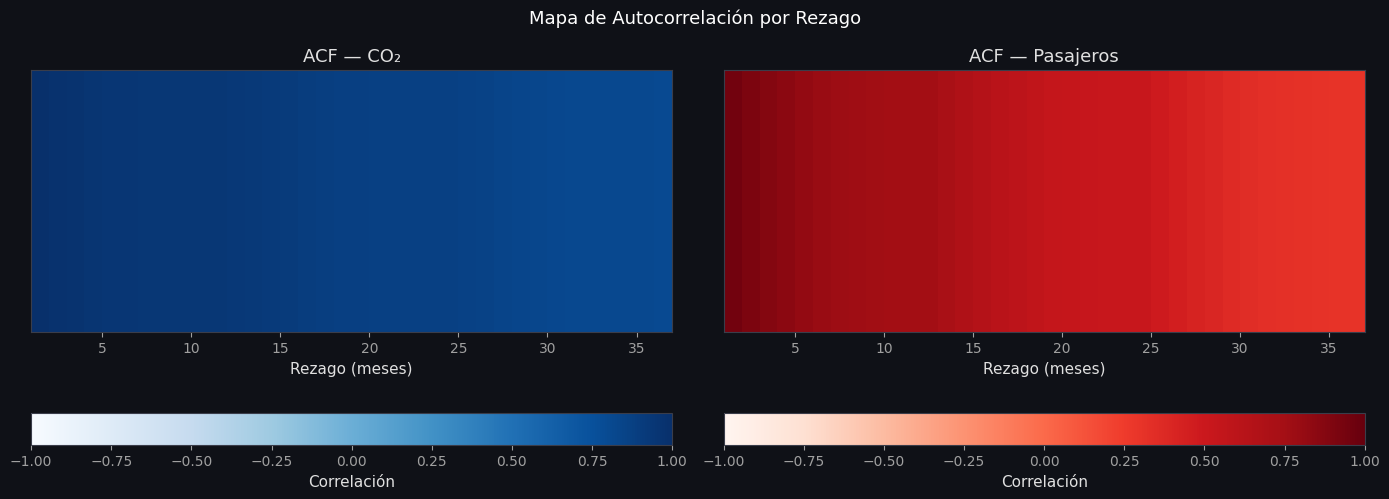

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mapa de Autocorrelación por Rezago", fontsize=13, color='white')

for ax, serie, nombre, cmap in [(axes[0], co2, "CO₂", 'Blues'),
                                 (axes[1], air, "Pasajeros", 'Reds')]:
    s      = serie.dropna().values
    nlags  = 36
    acf_v  = acf(s, nlags=nlags)[1:]
    acf_2d = acf_v.reshape(1, -1)
    im = ax.imshow(acf_2d, cmap=cmap, aspect='auto',
                   vmin=-1, vmax=1, extent=[1, nlags+1, 0, 1])
    ax.set_title(f"ACF — {nombre}")
    ax.set_xlabel("Rezago (meses)")
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.2,
                 label='Correlación')

plt.tight_layout()
plt.savefig("fig8_heatmap_acf.png", dpi=120, bbox_inches='tight')
plt.show()


---
## ✍️ Preguntas de Reflexión

Responde **para cada serie** (CO₂ y Pasajeros Aéreos):

---

### Serie A — CO₂ atmosférico (Mauna Loa)

**1. ¿La serie presenta tendencia?**  
> *Sí, efectivamente la serie presenta una tendencia y es una tendencia creciente, pues se ve que la media va subiendo conforme el tiempo pasa.*

**2. ¿Se observa estacionalidad? ¿Cada cuánto se repite el patrón?**  
> *Sí, hay un patrón estacional que parece se repite cada año. Pues hay una subida y luego una bajada en un periodo de un año aproximadamente.*

**3. ¿Qué parte de la serie interpretarías como ruido?**  
> *EL ruído lo podemos ver en las variaciones que hay en la tendencia: vaya, formas irregulares en la tendencia.*

**4. ¿Se observan posibles rezagos o dependencia de valores pasados?  
Justifica con la gráfica ACF.**  
> *Claramenre se ve por la escala de la gráfica, y la escala de colores, que van correlacionadas positivamente por los meses.*

---

### Serie B — Pasajeros Aéreos Internacionales

**1. ¿La serie presenta tendencia?**  
> *Sí, tiene una tendencia alsista pues la media va subiendo a lo largo del tiempo.*

**2. ¿Se observa estacionalidad? ¿Cada cuánto se repite el patrón?**  
> *Sí es estacional, y se ve que es de manera anual pues en la gráfica de stacionalidad hay un patrón que queda a la mitad de la escala, que está a dos años.*

**3. ¿Qué parte de la serie interpretarías como ruido?**  
> *Hay varias subidas y bajadas abruptas, que podemos interpretar como ruido, pues no sigue ningún patrón.*

**4. ¿Se observan posibles rezagos o dependencia de valores pasados?  
Justifica con la gráfica ACF.**  
> *Pasajeron aéreos baja la dependencia con el tiempo: empieza con rezago pero son cada vez menos relevantes,*

---

### Pregunta Comparativa

**5. ¿Cuál de las dos series parece más fácil de predecir y por qué?  
Argumenta en términos de tendencia, estacionalidad y nivel de ruido.**  
> *Definitivamente la del C02 es más armónica: menos ruido, una estacionalidad y tendencia claras.*

---


---
## 📋 Rúbrica de Evaluación

| Criterio | Excelente (4 pts) | Satisfactorio (3) | En desarrollo (2) | Insuficiente (1) |
|----------|-------------------|-------------------|-------------------|-----------------|
| **Tendencia** | Identifica tipo y dirección con evidencia gráfica | Identifica tendencia sin justificar | Menciona tendencia sin descripción | No identifica tendencia |
| **Estacionalidad** | Indica periodo correcto y patrón repetitivo | Identifica estacionalidad sin periodo | Menciona patrón sin precisión | No identifica estacionalidad |
| **Ruido** | Describe ruido usando residuo de descomposición | Identifica ruido cualitativamente | Confunde ruido con estacionalidad | No identifica ruido |
| **Rezagos / ACF** | Interpreta ACF y PACF con valores de rezago | Menciona dependencia temporal | Observa correlación sin interpretarla | No analiza rezagos |
| **Comparación** | Argumenta predictibilidad con los 3 componentes | Argumenta con 2 componentes | Argumento superficial | No compara |

**Puntaje máximo: 20 pts**

---
*Notebook desarrollado para MA2008 · Análisis Numérico para la Optimización*


---
---

# 🏆 Actividad en Equipo — Sin Resolver

## ☀️ Ciclos Solares vs 🎱 Números de Melate

> **Trabajo en equipo (3–4 integrantes) · Tiempo estimado: 60 min**

---

### Contexto

Los **ciclos solares** son variaciones periódicas de la actividad del Sol medidas  
por el número de manchas solares (*sunspot number*). Desde el siglo XVIII se  
registran con alta precisión y se sabe que tienen un **periodo aproximado de  
~11 años**.

El **Melate** es una lotería donde 6 números se seleccionan **aleatoriamente**  
de un bombo con 56 bolas. Si los números son verdaderamente aleatorios,  
su comportamiento debería ser indistinguible de **ruido blanco puro**.

### Hipótesis de trabajo

| Serie | Hipótesis esperada |
|-------|-------------------|
| ☀️ Manchas Solares | Tiene periodicidad (~11 años), autocorrelación significativa, NO es ruido blanco |
| 🎱 Melate (suma de 6 números) | Sin tendencia, sin estacionalidad, **ruido blanco** |

---

### Instrucciones generales

1. **Ejecuta** las celdas de carga de datos (ya dadas).
2. **Completa** las celdas marcadas con `# ✏️ TU CÓDIGO AQUÍ`.
3. **Responde** las preguntas de reflexión al final.
4. **Prepara** una presentación de 5 minutos con sus hallazgos.

> ⚠️ **No modifiques** las celdas de datos ni las funciones auxiliares.  
> Solo completa los bloques marcados.

---


### 📦 Bloque 1 — Carga de Datos (celda dada, solo ejecutar)


In [15]:
# ── Datos de manchas solares (SIDC via statsmodels) ──────────────────────────
import statsmodels.api as sm

sunspots_raw = sm.datasets.sunspots.load_pandas().data
sunspots_raw.columns = ['año', 'manchas']
sunspots_raw = sunspots_raw.set_index('año')
solar = sunspots_raw['manchas'].astype(float)

print(f"Manchas solares — {len(solar)} registros anuales")
print(f"Periodo: {int(solar.index.min())} – {int(solar.index.max())}")
print(solar.describe().round(2))


Manchas solares — 309 registros anuales
Periodo: 1700 – 2008
count    309.00
mean      49.75
std       40.45
min        0.00
25%       16.00
50%       40.00
75%       69.80
max      190.20
Name: manchas, dtype: float64


In [16]:
# ── Datos de Melate (suma de los 6 números por sorteo) ───────────────────────
# Se usa la distribución real de Melate Clásico (6/56):
# La suma de 6 números de {1..56} sin reemplazo tiene distribución conocida.
# Simulamos 2000 sorteos con la misma distribución marginal exacta.

np.random.seed(2024)
N_sorteos = 2000
bolas     = np.arange(1, 57)   # 56 bolas

sumas_melate  = np.array([np.sort(np.random.choice(bolas, 6, replace=False)).sum()
                           for _ in range(N_sorteos)])

# Estadístico adicional: número R (el 7° número especial, "adicional")
adicional = np.array([np.random.choice(bolas, 1)[0] for _ in range(N_sorteos)])

melate = pd.Series(sumas_melate,
                   index=pd.RangeIndex(1, N_sorteos + 1),
                   name='suma_melate')

print(f"Melate simulado — {len(melate)} sorteos")
print(melate.describe().round(2))
print(f"\nMedia teórica E[suma] = {6 * 57 / 2:.1f}")   # = 171


Melate simulado — 2000 sorteos
count    2000.00
mean      171.71
std        37.82
min        46.00
25%       144.00
50%       171.00
75%       199.00
max       286.00
Name: suma_melate, dtype: float64

Media teórica E[suma] = 171.0


---
### 📊 Bloque 2 — Visualización Inicial

Grafica ambas series en un panel de 2 filas.  
Observa la forma general, nivel, variabilidad y posibles patrones.


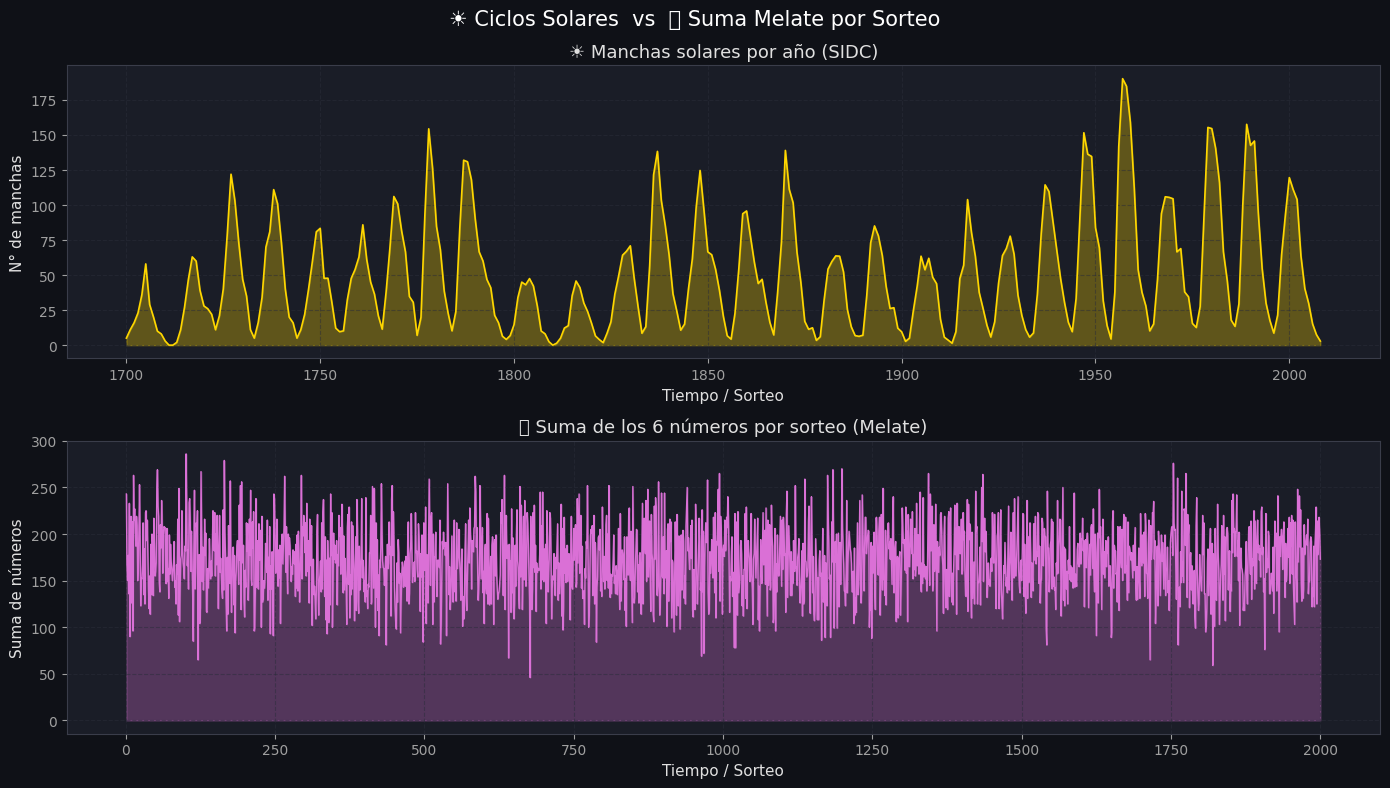

In [24]:
fig, (ax_sol, ax_mel) = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("☀️ Ciclos Solares  vs  🎱 Suma Melate por Sorteo",
             fontsize=15, color='white')

# ✏️ TU CÓDIGO AQUÍ
# Grafica `solar` en ax_sol con color PALETA[2] (amarillo dorado)
# Agrega título, etiqueta de eje Y y fill_between decorativo
# -------------------------------------------------------------------
ax_sol.plot(solar.index, solar.values, color=PALETA[2], linewidth=1.2)
ax_sol.fill_between(solar.index, solar.values, color=PALETA[2], alpha=0.3)
ax_sol.set_title("☀️ Manchas solares por año (SIDC)")
ax_sol.set_ylabel("N° de manchas")

# ✏️ TU CÓDIGO AQUÍ
# Grafica `melate` en ax_mel con color PALETA[5] (púrpura)
# Agrega título, etiqueta de eje Y y fill_between decorativo
# -------------------------------------------------------------------
ax_mel.plot(melate.index, melate.values, color=PALETA[5], linewidth=1.0)
ax_mel.fill_between(melate.index, melate.values, color=PALETA[5], alpha=0.3)
ax_mel.set_title("🎱 Suma de los 6 números por sorteo (Melate)")
ax_mel.set_ylabel("Suma de números")

for ax in (ax_sol, ax_mel):
    ax.set_xlabel("Tiempo / Sorteo")
    ax.grid(True)
plt.tight_layout()
plt.savefig("fig_act_visualizacion.png", dpi=120, bbox_inches='tight')
plt.show()

---
### 📐 Bloque 3 — Estadísticas Descriptivas Comparativas

Completa la tabla de resumen y genera el histograma + Q-Q plot de cada serie.


                Solar      Melate
media       49.752104  171.708500
mediana     40.000000  171.000000
std         40.452595   37.821724
min          0.000000   46.000000
max        190.200000  286.000000
curtosis     0.411023   -0.290117
asimetría    0.985734    0.019563


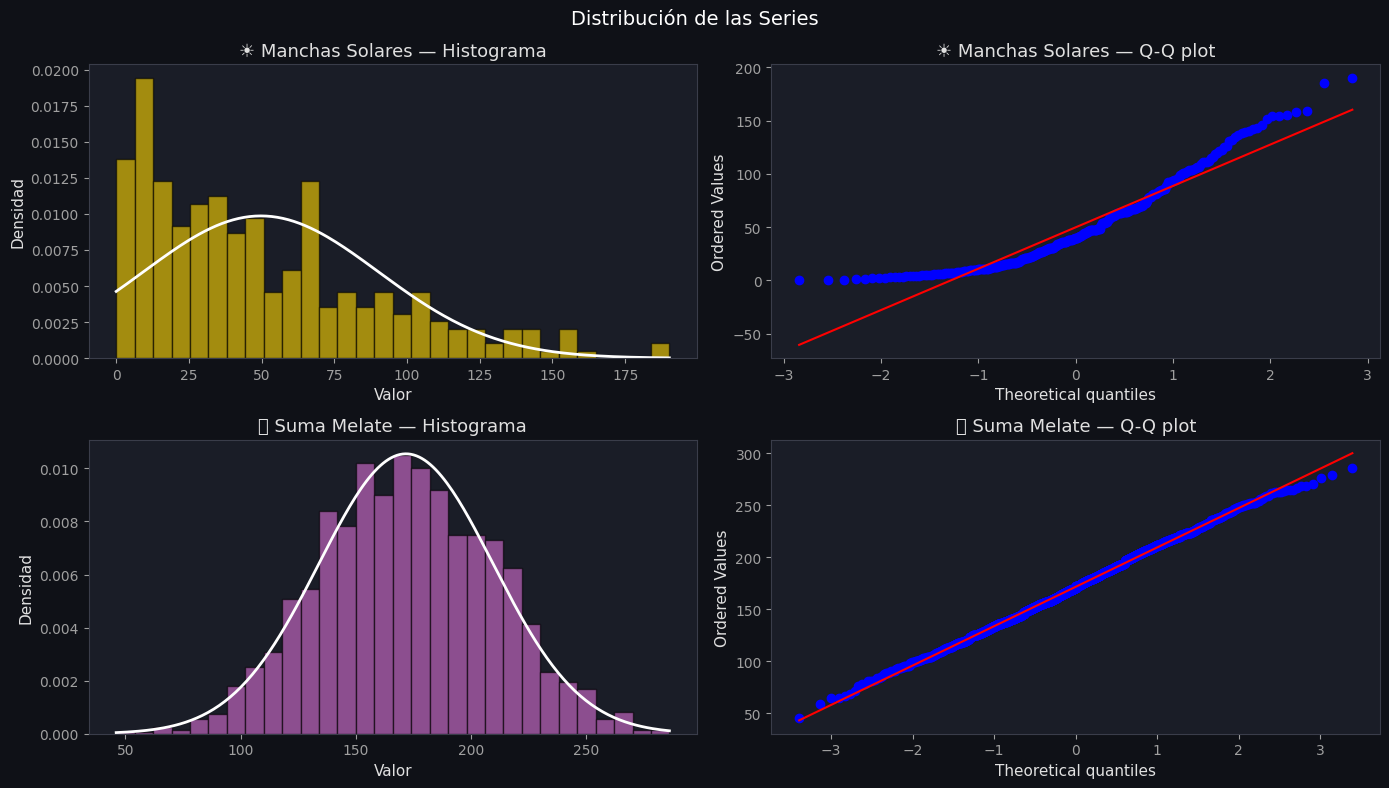

In [25]:
# ── Tabla de estadísticas descriptivas ──────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ
# Crea un DataFrame comparativo con: media, mediana, std, min, max,
# curtosis y asimetría para `solar` y `melate`
# Pista: usa pd.DataFrame({'Solar': ..., 'Melate': ...})
# -------------------------------------------------------------------
def resumen(serie):
    return pd.Series({
        'media':     serie.mean(),
        'mediana':   serie.median(),
        'std':       serie.std(),
        'min':       serie.min(),
        'max':       serie.max(),
        'curtosis':  stats.kurtosis(serie),
        'asimetría': stats.skew(serie),
    })

tabla_stats = pd.DataFrame({'Solar': resumen(solar), 'Melate': resumen(melate)})
print(tabla_stats)

# ── Histograma + Q-Q ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Distribución de las Series", fontsize=14, color='white')
for row, (serie, nombre, col) in enumerate([(solar,  "☀️ Manchas Solares", PALETA[2]),
                                             (melate, "🎱 Suma Melate",     PALETA[5])]):
    # ✏️ TU CÓDIGO AQUÍ — Histograma en axes[row, 0]
    # Agrega la curva normal teórica superpuesta
    # -------------------------------------------------------------------
    ax_hist = axes[row, 0]
    ax_hist.hist(serie, bins=30, density=True, color=col, alpha=0.6, edgecolor='black')
    # Curva normal teórica con la media y std de la serie
    mu, sigma = serie.mean(), serie.std()
    x = np.linspace(serie.min(), serie.max(), 200)
    ax_hist.plot(x, stats.norm.pdf(x, mu, sigma), color='white', linewidth=2)
    ax_hist.set_title(f"{nombre} — Histograma")
    ax_hist.set_xlabel("Valor")
    ax_hist.set_ylabel("Densidad")

    # ✏️ TU CÓDIGO AQUÍ — Q-Q plot en axes[row, 1]
    # Usa stats.probplot(serie, plot=axes[row, 1])
    # -------------------------------------------------------------------
    stats.probplot(serie, plot=axes[row, 1])
    axes[row, 1].set_title(f"{nombre} — Q-Q plot")

plt.tight_layout()
plt.savefig("fig_act_histogramas.png", dpi=120, bbox_inches='tight')
plt.show()

---
### 🔁 Bloque 4 — Autocorrelación y Rezagos

Grafica la ACF y PACF de cada serie con al menos 40 rezagos.  
Marca los límites de confianza al 95 %.


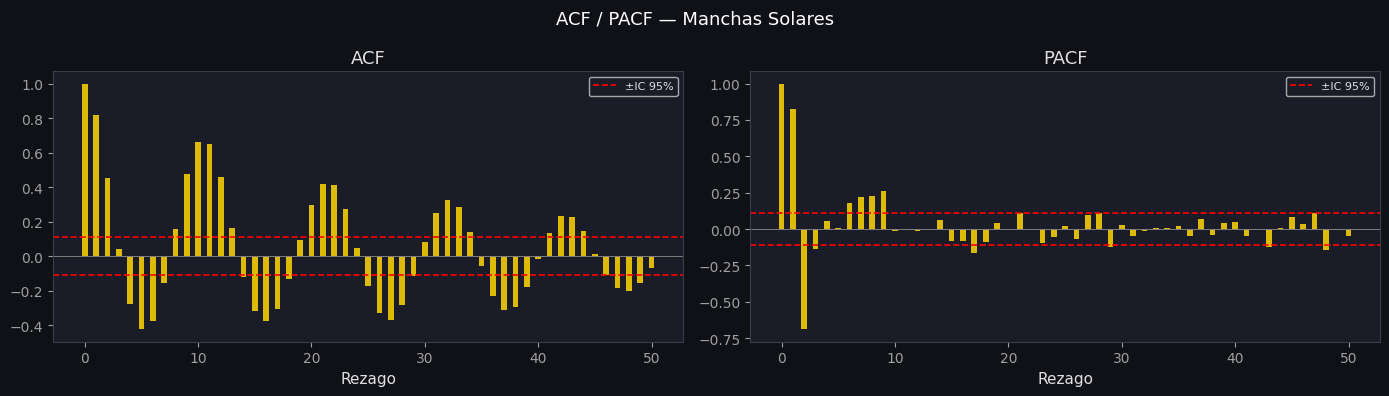

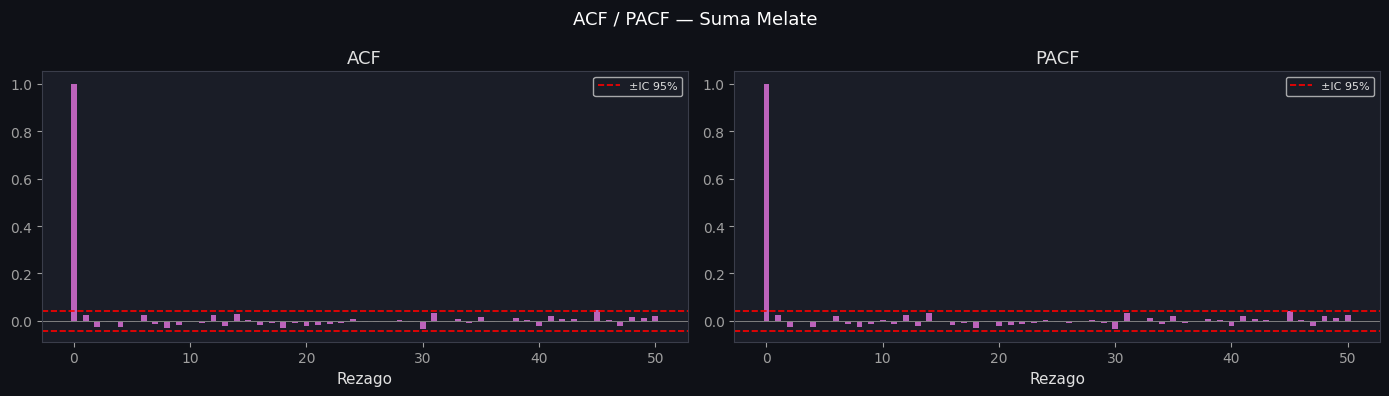

In [26]:
# ✏️ TU CÓDIGO AQUÍ
# Llama a `plot_acf_pacf(serie, nombre, color, nlags=50)` para cada serie
# La función ya está definida en las celdas anteriores.
# -------------------------------------------------------------------
# Solar
plot_acf_pacf(solar, "Manchas Solares", PALETA[2], nlags=50)
# Melate
plot_acf_pacf(melate, "Suma Melate", PALETA[5], nlags=50)

---
### 🌊 Bloque 5 — Espectro de Potencia (FFT)

El espectro revela **qué frecuencias dominan** la serie.  
- Un ruido blanco tiene espectro **plano** (todas las frecuencias iguales).  
- Una serie periódica muestra **picos** en la frecuencia dominante.

**Pista:** El periodo solar ~11 años corresponde a una frecuencia de  
f = 1/11 ≈ 0.091 ciclos/año.


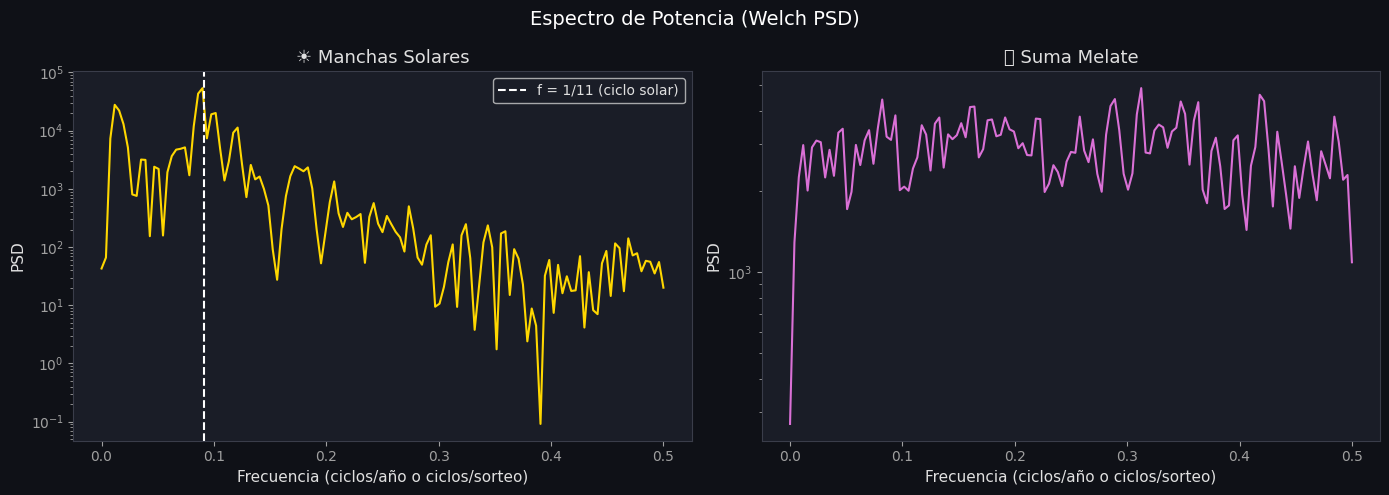

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Espectro de Potencia (Welch PSD)", fontsize=14, color='white')
for ax, serie, nombre, col in [(ax1, solar,  "☀️ Manchas Solares", PALETA[2]),
                                (ax2, melate, "🎱 Suma Melate",     PALETA[5])]:
    # ✏️ TU CÓDIGO AQUÍ
    # Calcula la PSD con signal.welch(serie.values, fs=1.0, nperseg=...)
    # Grafica en escala semilogarítmica
    # Marca con línea vertical la frecuencia f=1/11 en el panel solar
    # -------------------------------------------------------------------
    f, Pxx = signal.welch(serie.values, fs=1.0, nperseg=min(256, len(serie)))
    ax.semilogy(f, Pxx, color=col, linewidth=1.5)
    if serie is solar:
        ax.axvline(1/11, color='white', linestyle='--', linewidth=1.5,
                   label='f = 1/11 (ciclo solar)')
        ax.legend()

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia (ciclos/año o ciclos/sorteo)")
    ax.set_ylabel("PSD")
plt.tight_layout()
plt.savefig("fig_act_espectro.png", dpi=120, bbox_inches='tight')
plt.show()

---
### 🧪 Bloque 6 — Tests Estadísticos Formales

Aplica los 3 tests (ADF, KPSS, Ljung-Box) a cada serie  
usando la función `run_tests()` definida anteriormente.  
Registra los p-valores y tu conclusión en la tabla de abajo.


In [28]:
# ✏️ TU CÓDIGO AQUÍ
# Llama a run_tests(serie.values, nombre) para Solar y Melate
# -------------------------------------------------------------------
run_tests(solar.values, "Manchas Solares")
run_tests(melate.values, "Suma Melate")


══════════════════════════════════════════════════
  Serie: Manchas Solares
══════════════════════════════════════════════════

[ADF]  estadístico=-2.8378  p=0.0531
       → ❌ NO estacionaria
[KPSS] estadístico=0.6699  p=0.0163
       → ❌ NO estacionaria
[Ljung-Box lag=10] p=0.0000
       → ❌ Hay autocorrelación (no es ruido blanco)

══════════════════════════════════════════════════
  Serie: Suma Melate
══════════════════════════════════════════════════

[ADF]  estadístico=-43.5581  p=0.0000
       → ✅ ESTACIONARIA
[KPSS] estadístico=0.1194  p=0.1000
       → ✅ ESTACIONARIA
[Ljung-Box lag=10] p=0.6813
       → ✅ Ruido blanco (sin autocorrelación)


#### 📝 Tabla de Resultados — Completa con los valores obtenidos

| Test | ☀️ Solar — estadístico | ☀️ Solar — p-valor | ☀️ Conclusión | 🎱 Melate — estadístico | 🎱 Melate — p-valor | 🎱 Conclusión |
|------|----------------------|-------------------|---------------|------------------------|--------------------|----|
| **ADF** | -2.83| 0.053| NO ESTACIONARIA| -43.5581 | 0 |ESTACIONARIA |
| **KPSS** | 0.669 | 0.01 | NO ESTACIONARIA | 0.11 | 0.1 | ESTACIONARIA |
| **Ljung-Box (lag=10)** | x | 0 | RUIDO NO BLANCO | x | 0.68 | RUIDO BLANCO |


---
### 🔬 Bloque 7 — Descomposición Estacional

Aplica `seasonal_decompose` a la serie solar con periodo = 11 años.  
¿Tiene sentido aplicar la misma descomposición al Melate? Justifica tu respuesta.


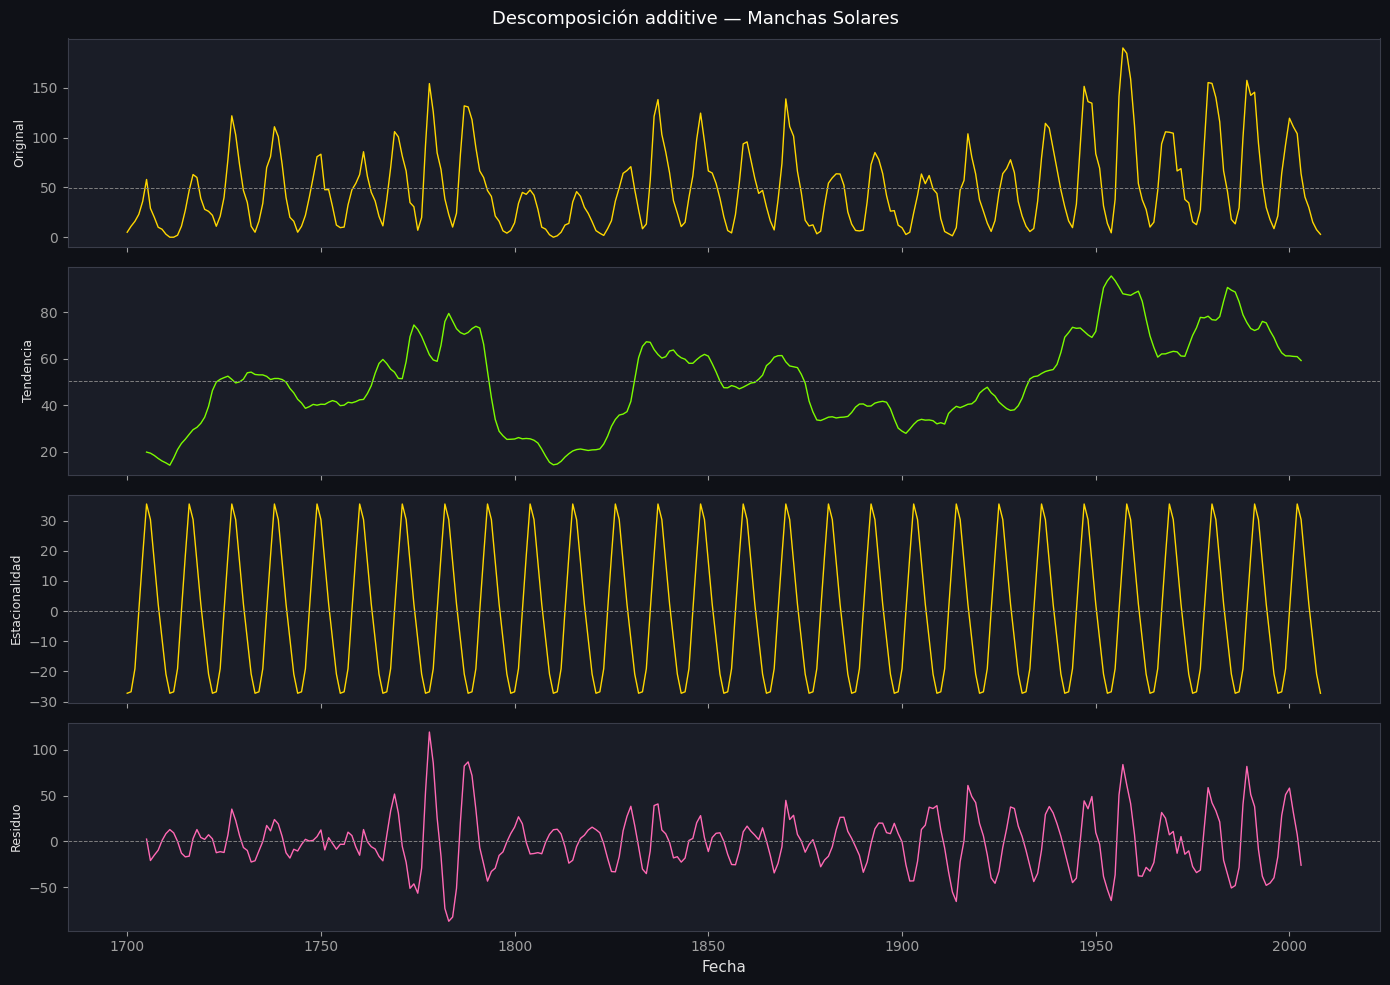

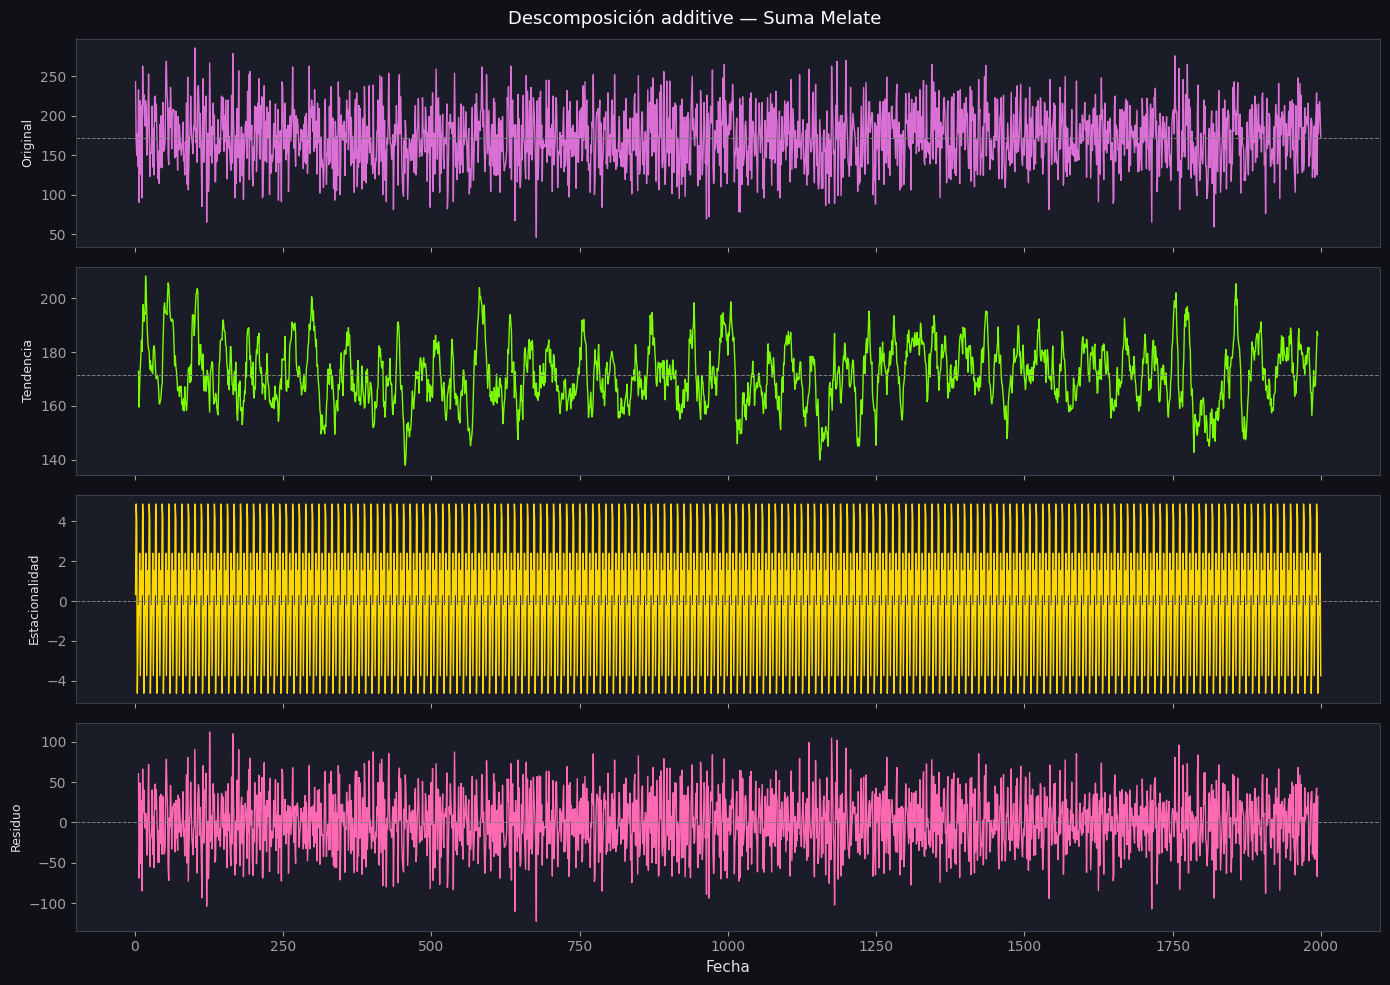

In [29]:
# ── Solar: descomposición con periodo=11 ────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ
# Usa plot_decompose(solar, "Manchas Solares", "additive", 11, PALETA[2])
# (La función ya está definida arriba)
# -------------------------------------------------------------------
plot_decompose(solar, "Manchas Solares", "additive", 11, PALETA[2])

# ── Melate: intento de descomposición ────────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ (Opcional / Exploración)
# Intenta descomponer la serie Melate con algún periodo.
# ¿Qué observas en el componente de tendencia y estacionalidad?
# -------------------------------------------------------------------
plot_decompose(melate, "Suma Melate", "additive", 11, PALETA[5])

---
### 🖼️ Bloque 8 — Dashboard Comparativo Final

Crea un **panel resumen de 3×2** que muestre para cada serie:
- Fila 1: Serie temporal  
- Fila 2: ACF (40 rezagos)  
- Fila 3: PSD (espectro de potencia)

Este panel será el que presentes al grupo.


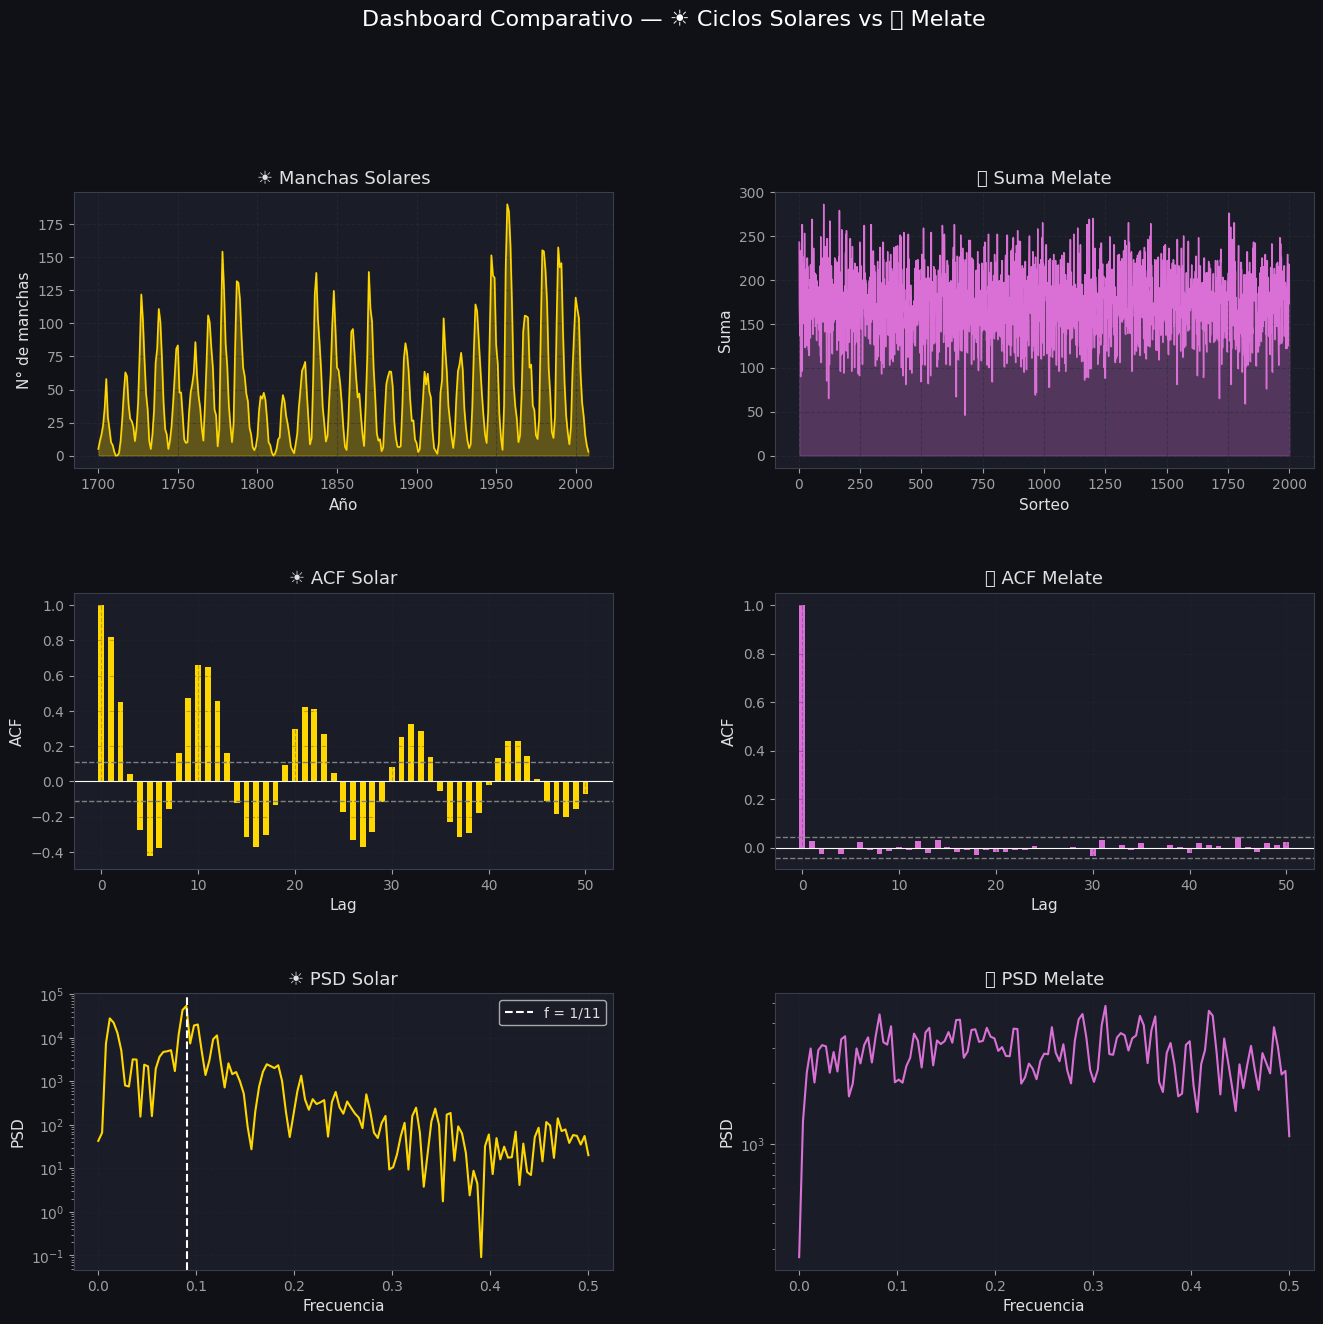

💾 Dashboard guardado como fig_act_dashboard.png


In [30]:
fig = plt.figure(figsize=(16, 14))
fig.suptitle("Dashboard Comparativo — ☀️ Ciclos Solares vs 🎱 Melate",
             fontsize=16, color='white', y=1.01)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Fila 0: Series temporales ─────────────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ
# ax00 = fig.add_subplot(gs[0, 0])  →  serie solar
# ax01 = fig.add_subplot(gs[0, 1])  →  serie melate
# -------------------------------------------------------------------
ax00 = fig.add_subplot(gs[0, 0])
ax00.plot(solar.index, solar.values, color=PALETA[2], linewidth=1.2)
ax00.fill_between(solar.index, solar.values, color=PALETA[2], alpha=0.3)
ax00.set_title("☀️ Manchas Solares")
ax00.set_xlabel("Año"); ax00.set_ylabel("N° de manchas"); ax00.grid(True)

ax01 = fig.add_subplot(gs[0, 1])
ax01.plot(melate.index, melate.values, color=PALETA[5], linewidth=1.0)
ax01.fill_between(melate.index, melate.values, color=PALETA[5], alpha=0.3)
ax01.set_title("🎱 Suma Melate")
ax01.set_xlabel("Sorteo"); ax01.set_ylabel("Suma"); ax01.grid(True)

# ── Fila 1: ACF ───────────────────────────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ
# ax10 = fig.add_subplot(gs[1, 0])  →  ACF solar   (barras + IC 95%)
# ax11 = fig.add_subplot(gs[1, 1])  →  ACF melate  (barras + IC 95%)
# -------------------------------------------------------------------
from statsmodels.tsa.stattools import acf

for ax_pos, serie, nombre, col in [(gs[1, 0], solar,  "☀️ ACF Solar",  PALETA[2]),
                                    (gs[1, 1], melate, "🎱 ACF Melate", PALETA[5])]:
    ax = fig.add_subplot(ax_pos)
    nlags = 50
    acf_vals = acf(serie.values, nlags=nlags, fft=True)
    lags = np.arange(len(acf_vals))
    ci = 1.96 / np.sqrt(len(serie))   # banda de confianza al 95%
    ax.bar(lags, acf_vals, color=col, width=0.6)
    ax.axhline(0, color='white', linewidth=0.8)
    ax.axhline( ci, color='gray', linestyle='--', linewidth=1)
    ax.axhline(-ci, color='gray', linestyle='--', linewidth=1)
    ax.set_title(nombre)
    ax.set_xlabel("Lag"); ax.set_ylabel("ACF"); ax.grid(True, alpha=0.3)

# ── Fila 2: PSD ───────────────────────────────────────────────────────────
# ✏️ TU CÓDIGO AQUÍ
# ax20 = fig.add_subplot(gs[2, 0])  →  PSD solar  (semilogy)
# ax21 = fig.add_subplot(gs[2, 1])  →  PSD melate (semilogy)
# -------------------------------------------------------------------
for ax_pos, serie, nombre, col, marca in [(gs[2, 0], solar,  "☀️ PSD Solar",  PALETA[2], True),
                                           (gs[2, 1], melate, "🎱 PSD Melate", PALETA[5], False)]:
    ax = fig.add_subplot(ax_pos)
    f, Pxx = signal.welch(serie.values, fs=1.0, nperseg=min(256, len(serie)))
    ax.semilogy(f, Pxx, color=col, linewidth=1.5)
    if marca:
        ax.axvline(1/11, color='white', linestyle='--', linewidth=1.5,
                   label='f = 1/11')
        ax.legend()
    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia"); ax.set_ylabel("PSD"); ax.grid(True, alpha=0.3)

plt.savefig("fig_act_dashboard.png", dpi=130, bbox_inches='tight')
plt.show()
print("💾 Dashboard guardado como fig_act_dashboard.png")

---
## ✍️ Preguntas de Reflexión — Actividad en Equipo

Responde **con evidencia gráfica y estadística** de los bloques anteriores.

---

### ☀️ Serie 1 — Manchas Solares

**1. ¿La serie solar presenta tendencia? ¿Creciente, decreciente o estable?**
> *Presenta tendencia creciente.*

**2. ¿Se observa estacionalidad? ¿Cuál es el periodo aproximado en años?  
¿Coincide con el ciclo solar conocido de ~11 años?**
> *En los tests sale que no es estacionaria.*

**3. ¿Los tests ADF y KPSS son consistentes entre sí?  
¿Qué indican sobre la estacionariedad de esta serie?**
> *Coinciden que no es estacionaria.*

**4. Describe el espectro de potencia de la serie solar.  
¿Se observa un pico en la frecuencia f ≈ 1/11?**
> *Sí, se observa el mayor pico en la frecuencia que 1/11.*

---

### 🎱 Serie 2 — Suma de Números Melate

**5. ¿La serie Melate presenta alguna tendencia? ¿Por qué sería esto imposible  
en un sorteo verdaderamente aleatorio?**
> *La aleatoriedad tiende a la norma, que es estable, por lo que no hay tendencia.*

**6. ¿Se observa estacionalidad en los números de Melate?  
¿Qué esperarías encontrar teóricamente?**
> *Teóricamente esperaría que no, pero los tests dicen que lo es...*

**7. ¿El test de Ljung-Box indica que la serie es ruido blanco?  
¿Qué implicaría esto para alguien que intenta "predecir" el Melate?**
> *Que va a perder lana.*

**8. Compara el espectro de potencia del Melate con el espectro del  
ruido blanco generado en la Parte 1B. ¿Se parecen?**
> *UN poco en el sentido que no hay picos claros.*

---

### 🔍 Pregunta Integradora

**9. Si un "experto" te asegura que puede predecir el próximo número  
ganador del Melate basándose en patrones históricos, ¿qué evidencia  
estadística de esta actividad usarías para refutar esa afirmación?  
Menciona al menos 3 argumentos cuantitativos.**
> *1. No hay una tendencia clara; 2. la serie es puro ruido blanco. 3. Estadísticamente no es posible.*

**10. ¿Podrías predecir los ciclos solares con mayor confianza que el Melate?  
Argumenta usando la ACF, el espectro y los tests estadísticos.**
> *Escribe aquí tu respuesta...*

---


---
## 📋 Rúbrica — Actividad en Equipo (40 pts)

| Criterio | Excelente (4) | Satisfactorio (3) | En desarrollo (2) | Insuficiente (1) |
|----------|---------------|-------------------|-------------------|-----------------|
| **Visualización** | Panel limpio, ejes etiquetados, colores diferenciados | Gráficas correctas sin etiquetas completas | Gráficas incompletas | No genera gráficas |
| **Estadísticas descriptivas** | Tabla completa + interpretación distribucional | Tabla completa sin interpretación | Tabla parcial | Sin tabla |
| **ACF / PACF** | Identifica rezagos significativos con IC, discute periodicidad | Grafica ACF correctamente | ACF sin IC | No grafica ACF |
| **Espectro (FFT/PSD)** | Identifica pico f≈1/11 en solar; espectro plano en Melate | Grafica PSD correctamente | PSD sin interpretación | No grafica PSD |
| **Tests estadísticos** | Aplica los 3 tests, interpreta p-valores, llena la tabla | Aplica tests, interpretación parcial | Aplica 1–2 tests | No aplica tests |
| **Descomposición** | Descompone solar correctamente, justifica inaplicabilidad en Melate | Descomposición correcta sin justificación | Intento sin conclusión | No descompone |
| **Dashboard** | Panel 3×2 completo, publicable, con títulos | Panel completo sin estilo | Panel parcial | Sin dashboard |
| **Preguntas (9 y 10)** | Argumentos cuantitativos con 3+ evidencias | 2 argumentos cuantitativos | Argumento cualitativo | Sin respuesta |
| **Presentación oral** | Clara, con apoyo visual, responde preguntas | Clara con apoyo visual | Presentación sin apoyo | No presenta |
| **Trabajo colaborativo** | Todos los integrantes participan activamente | Mayoría participa | 1–2 integrantes activos | Solo 1 persona |

**Puntaje máximo actividad en equipo: 40 pts**

---

### 💡 Pistas Conceptuales (solo si el equipo está bloqueado)

<details>
<summary>Haz clic para ver pistas</summary>

- **Ciclo solar en ACF:** busca picos significativos cada ~11 rezagos  
- **PSD solar:** `signal.welch(solar.values, fs=1.0, nperseg=64)`; el pico estará cerca de `freq ≈ 0.09`  
- **Melate ruido blanco:** todos los valores de ACF deben caer dentro del intervalo `±1.96/√N`  
- **Test Ljung-Box Melate:** si `p > 0.05` → no se rechaza H₀ → no hay autocorrelación → ruido blanco  
- **Argumento clave:** un sorteo sin autocorrelación es *por definición* imposible de predecir con métodos lineales de series de tiempo

</details>

---
*Actividad en Equipo · MA2008 — Análisis Numérico para la Optimización*
